<a href="https://colab.research.google.com/github/Eniiifeoluwa/RECTLAB_INTERNSHIP/blob/main/Dog_and_Cat_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
device = torch.device("cuda" if
torch.cuda.is_available() else 'cpu')
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn.init as init



# Define the neural network class
class NeuralNetwork(nn.Module):
    def __init__(self, inputs, hidden1, hidden2, hidden3, output):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(inputs, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.bn3 = nn.BatchNorm1d(hidden3)
        self.fc4 = nn.Linear(hidden3, output)
        #self.bn4 = nn.BatchNorm1d(hidden4)
        #self.fc5 = nn.Linear(hidden4, hidden5)
        #self.bn5 = nn.BatchNorm1d(hidden5)
        #self.fc6 = nn.Linear(hidden5, output)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()


        init.xavier_uniform_(self.fc1.weight)
        init.xavier_uniform_(self.fc2.weight)
        init.xavier_uniform_(self.fc3.weight)
        init.xavier_uniform_(self.fc4.weight)
        #init.xavier_uniform_(self.fc5.weight)
        #init.xavier_uniform_(self.fc6.weight)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        #x = self.dropout(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.bn3(x)
        #x = self.dropout(x)
        x = self.relu(x)
        x = self.fc4(x)
        #x = self.bn4(x)
       # x = self.dropout(x)
        #x = self.sigmoid(x)
        #x = self.fc5(x)
        #x = self.bn5(x)
        #x = self.sigmoid(x)
        #x = self.fc6(x)
        x = self.sigmoid(x)
        return x





In [ ]:
image_size = (400, 400)
train_folder = '/content/drive/My Drive/Animal classification/train'
test_folder = '/content/drive/My Drive/Animal classification/test'
# Create image data loaders

# Create image data loaders
train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

])

train_dataset = ImageFolder(train_folder, transform=train_transform)

#train_size = int(0.6 * len(full_training_dataset))
#val_size = len(full_training_dataset) - train_size
#train_dataset, val_dataset = random_split(full_training_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, shuffle=True)
#val_loader = DataLoader(val_dataset, shuffle=False)
test_dataset = ImageFolder(test_folder, transform=test_transform)
test_loader = DataLoader(test_dataset, shuffle=False)


In [ ]:
# Neural network parameters
input_size = image_size[0] * image_size[1] * 3  # RGB
hidden1 = 300
hidden2 = 200
hidden3= 100
hidden4 = 100
hidden5 = 50
output = 1

model = NeuralNetwork(input_size, hidden1, hidden2, hidden3, output).to(device)
model.train()  # Setting the model to training mode



NeuralNetwork(
  (fc1): Linear(in_features=480000, out_features=300, bias=True)
  (bn1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=300, out_features=200, bias=True)
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_features=100, bias=True)
  (bn3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=100, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.25, inplace=False)
  (relu): ReLU()
)

In [ ]:
criterion = nn.CrossEntropyLoss()
lossi  = []
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, weight_decay=0.01)# Setting up the optimizer with L2 regularization

# Training the neural network based on batch size
steps = 2000
batch_size = 128
for step in range(steps):
  mini_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
  for images, labels in mini_loader:
    images, labels = images.to(device), labels.to(device)
    images = images.view(images.size(0), -1)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels.float().view(-1, 1))

    # Setting the L1 regularization
    l1_lambda = 0.01
    l1_reg = torch.tensor(0., device = device)
    for param in model.parameters():
        l1_reg += torch.norm(param, 1)
    loss += l1_lambda * l1_reg


    loss.backward()
    optimizer.step()
    lossi.append(loss.item())

  print(f"Step {step+1}, Loss: {loss.item()}")
#torch.save(model.state_dict(), 'NeuralNetwork.pth')

Step 1, Loss: 2540.5546875
Step 2, Loss: 2469.814697265625
Step 3, Loss: 2400.0966796875
Step 4, Loss: 2331.402099609375
Step 5, Loss: 2263.730224609375
Step 6, Loss: 2197.081787109375
Step 7, Loss: 2131.454833984375
Step 8, Loss: 2066.8515625
Step 9, Loss: 2003.26953125
Step 10, Loss: 1940.7095947265625
Step 11, Loss: 1879.172119140625
Step 12, Loss: 1818.6588134765625
Step 13, Loss: 1759.1669921875
Step 14, Loss: 1700.6981201171875
Step 15, Loss: 1643.2490234375
Step 16, Loss: 1586.8231201171875
Step 17, Loss: 1531.4185791015625
Step 18, Loss: 1477.0364990234375
Step 19, Loss: 1423.676513671875
Step 20, Loss: 1371.3392333984375
Step 21, Loss: 1320.02294921875
Step 22, Loss: 1269.72998046875
Step 23, Loss: 1220.4586181640625
Step 24, Loss: 1172.2105712890625
Step 25, Loss: 1124.9837646484375
Step 26, Loss: 1078.779541015625
Step 27, Loss: 1033.595947265625
Step 28, Loss: 989.4341430664062
Step 29, Loss: 946.2938842773438
Step 30, Loss: 904.1760864257812
Step 31, Loss: 863.07958984375


In [ ]:
# Evaluating the model
model.eval()  # Calling the eval() function to set the model to evaluation mode
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)
        outputs = model(images)
        predicted = torch.round(outputs)
        total += labels.size(0)
        correct += (predicted == labels.float().view(-1, 1)).sum().item()

    accuracy = correct / total
    print(f'Accuracy: {accuracy * 100}%')


NameError: name 'model' is not defined

In [3]:
!save_snapshot

/bin/bash: line 1: save_snapshot: command not found


In [ ]:
torch.save(model.state_dict(), 'NeuralNetwork.pth')
#torch.save(model.state_dict(), 'NeuralNetwork.pth')

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import os

# Get the current working directory
current_dir = os.getcwd()
print("Current Directory:", current_dir)

# List files in the current directory to find your model file
files = os.listdir(current_dir)
print("Files in Directory:", files)


Current Directory: C:\Users\HP\Jupyter Notebooks\INTERNSHIP
Files in Directory: ['.ipynb_checkpoints', 'Activation function with torch.ipynb', 'BUILDING MICROGRAD.ipynb', 'Building Neural Network.ipynb', 'CHATGPT TOKENIZER.ipynb', 'CHATGPT.ipynb', 'CLASSIFIER.ipynb', 'Dog and Cat classification project.ipynb', 'EUNICE AREKETE .pdf', 'Learning  Neural Network.ipynb', 'Makemore.ipynb', 'Malaria classification.ipynb', 'N-gram Model.ipynb', 'names.txt', 'NeuralNetwork.pth', 'NeuralNetwork.zip', 'Ngram Model Project.ipynb', 'Personal Project.ipynb', 'PLAY.ipynb', 'R studio.ipynb', 'tiny-shakespeare.txt', 'TRAINING A DEEPER NEURAL NETWORK.ipynb', 'WaveNet.ipynb']


In [ ]:

# Plotting the loss curve
plt.plot(range(len(lossi)), lossi)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()


The predicted class is: dog


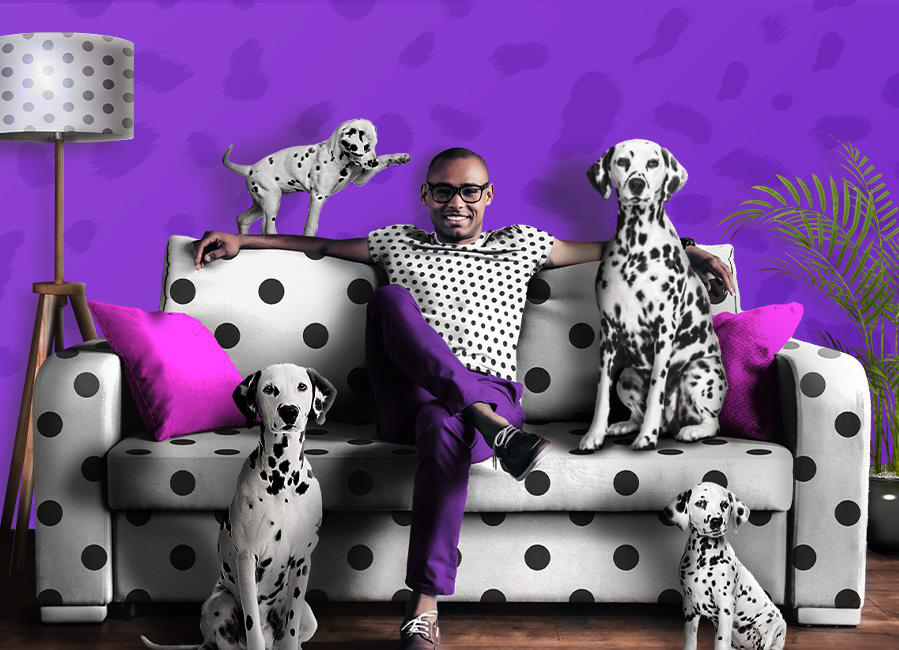

In [ ]:
from PIL import Image
image_path = "C:/Users/HP/Documents/AYOMIDE's  BOOKS/Data files/Animal classification/train/dogs/dog_9.jpg"
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((400, 400)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)  # Batch dimension


# Making a prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor.view(image_tensor.size(0), -1))
    prediction = torch.round(output).item()

# Interpreting the prediction
class_names = ['cat', 'dog']
predicted_class = class_names[int(prediction)]
print(f'The predicted class is: {predicted_class}')
image

The predicted class is: dog


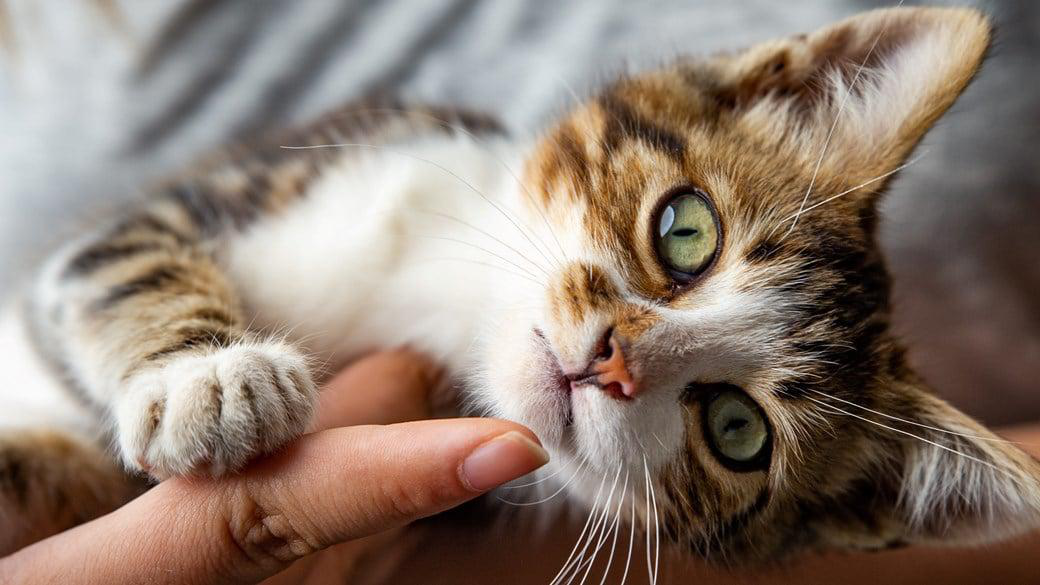

In [ ]:
from PIL import Image
image_path = "C:/Users/HP/Documents/AYOMIDE's  BOOKS/Data files/Animal classification/train/cats/cat_24.jpg"
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((400, 400)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)  # Batch dimension


# Making a prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor.view(image_tensor.size(0), -1))
    prediction = torch.round(output).item()

# Interpreting the prediction
class_names = ['cat', 'dog']
predicted_class = class_names[int(prediction)]
print(f'The predicted class is: {predicted_class}')
image